# Arabic Handwritten Characters Classifier

## Data Loading

In [1]:
import pandas as pd

train_labels = pd.read_csv('data/labels/train.csv', header=None) - 1
test_labels = pd.read_csv('data/labels/test.csv', header=None) - 1

In [2]:
train_labels.head().values

array([[0],
       [0],
       [0],
       [0],
       [0]])

In [3]:
train_labels.info()

<class 'pandas.DataFrame'>
RangeIndex: 13440 entries, 0 to 13439
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       13440 non-null  int64
dtypes: int64(1)
memory usage: 105.1 KB


In [4]:
import tensorflow as tf

train_ds = tf.keras.utils.image_dataset_from_directory(
    'data/images/train',
    labels=train_labels[0].values.tolist(),
    seed=42,
    shuffle=True,
    validation_split=0.2,
    subset='training',
    image_size=(32, 32),
    batch_size=32,
    color_mode='grayscale',
    verbose=True
)

Found 13440 files belonging to 28 classes.
Using 10752 files for training.


In [5]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    'data/images/train',
    labels=train_labels[0].values.tolist(),
    seed=42,
    shuffle=True,
    validation_split=0.2,
    subset='validation',
    image_size=(32, 32),
    batch_size=32,
    color_mode='grayscale',
    verbose=True
)

Found 13440 files belonging to 28 classes.
Using 2688 files for validation.


In [6]:
test_ds = tf.keras.utils.image_dataset_from_directory(
    'data/images/test',
    labels=test_labels[0].values.tolist(),
    seed=42,
    shuffle=True,
    image_size=(32, 32),
    batch_size=32,
    color_mode='grayscale',
    verbose=True
)

Found 3360 files belonging to 28 classes.


## Visualization

In [7]:
class_names = ['أ', 'ب', 'ت', 'ث', 'ج', 'ح', 'خ', 'د', 'ذ', 'ر', 'ز', 'س', 'ش', 'ص', 'ض', 'ط', 'ظ', 'ع', 'غ', 'ف', 'ق', 'ك', 'ل', 'م', 'ن', 'ه', 'و', 'ي']

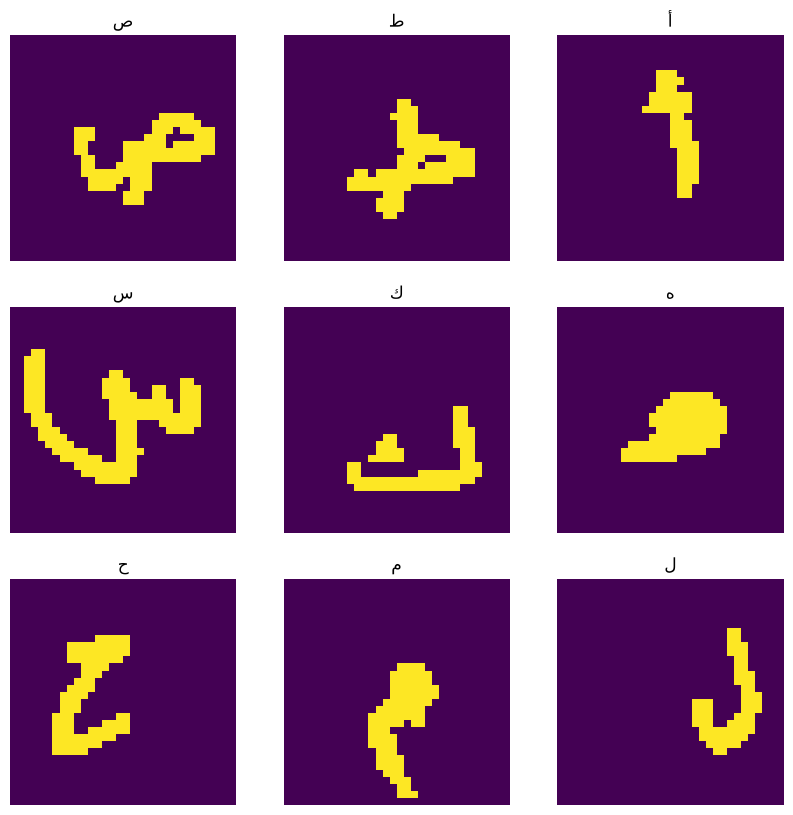

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 10))
for images, labels in test_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

## Modelling

### Training

In [9]:
model = tf.keras.Sequential([
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(filters=64, kernel_size=5, padding='same', activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.MaxPool2D(),

    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Conv2D(filters=128, kernel_size=3, padding='same', activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Conv2D(filters=128, kernel_size=3, padding='same', activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.MaxPool2D(),

    tf.keras.layers.GlobalMaxPooling2D(),

    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(128, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(64, activation='relu', kernel_initializer='he_normal'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(28, activation='softmax')
])

In [10]:
model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy'],
)

In [11]:
history = model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds
)

Epoch 1/10


c:\Users\Seif Adin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


336/336 ━━━━━━━━━━━━━━━━━━━━ 71s 193ms/step - accuracy: 0.2010 - loss: 2.8216 - val_accuracy: 0.5618 - val_loss: 1.5675
Epoch 2/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 65s 194ms/step - accuracy: 0.4355 - loss: 1.8030 - val_accuracy: 0.8058 - val_loss: 0.9067
Epoch 3/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 65s 193ms/step - accuracy: 0.5844 - loss: 1.3193 - val_accuracy: 0.7020 - val_loss: 0.9211
Epoch 4/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 65s 194ms/step - accuracy: 0.6598 - loss: 1.0767 - val_accuracy: 0.8843 - val_loss: 0.4737
Epoch 5/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 64s 192ms/step - accuracy: 0.7225 - loss: 0.8933 - val_accuracy: 0.9007 - val_loss: 0.3805
Epoch 6/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 64s 192ms/step - accuracy: 0.7527 - loss: 0.7933 - val_accuracy: 0.8973 - val_loss: 0.3648
Epoch 7/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 65s 195ms/step - accuracy: 0.7826 - loss: 0.7005 - val_accuracy: 0.9077 - val_loss: 0.3037
Epoch 8/10
336/336 ━━━━━━━━━━━━━━━━━━━━ 65s 193ms/step - accuracy: 0.8071 - loss: 0.6397 - val

The Model takes around 10 minutes to train getting an accuracy of around 93% on the validation set.

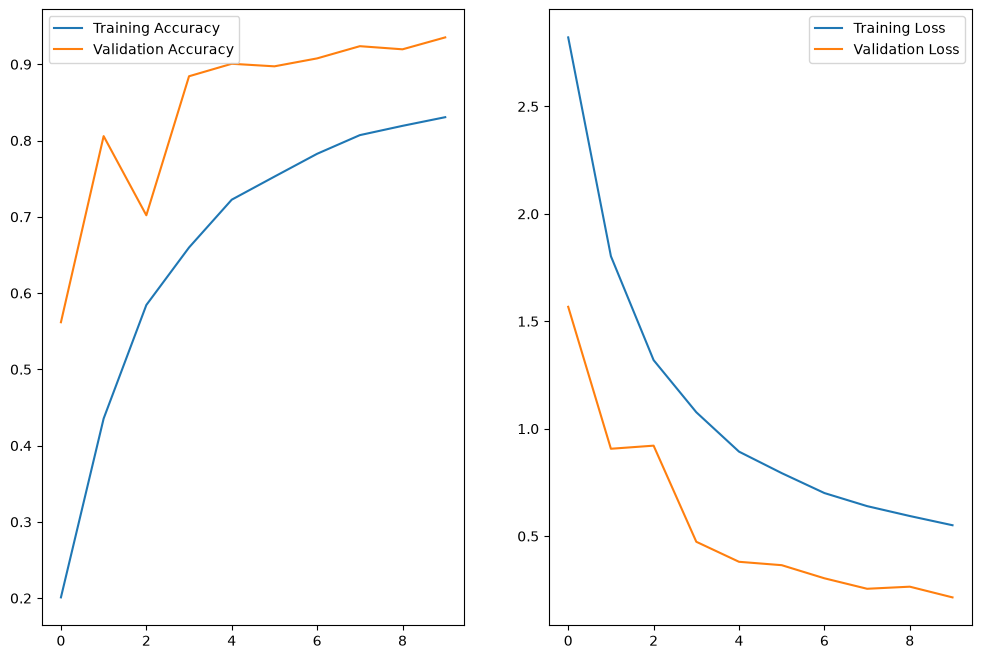

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12,8))

axes[0].plot(history.history['accuracy'], label='Training Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Training Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].legend()

plt.show()

### Evaluating

In [13]:
images, labels = next(iter(test_ds))
new_images = images[:9]
new_labels = labels[:9]

new_labels

<tf.Tensor: shape=(9,), dtype=int32, numpy=array([ 5, 14, 22, 22, 20, 24, 15, 17,  4], dtype=int32)>

In [14]:
import numpy as np

predictions = np.argmax(model.predict(new_images), axis=1)

predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 273ms/step


array([ 5, 14, 22, 22, 20,  2, 15, 17,  4])

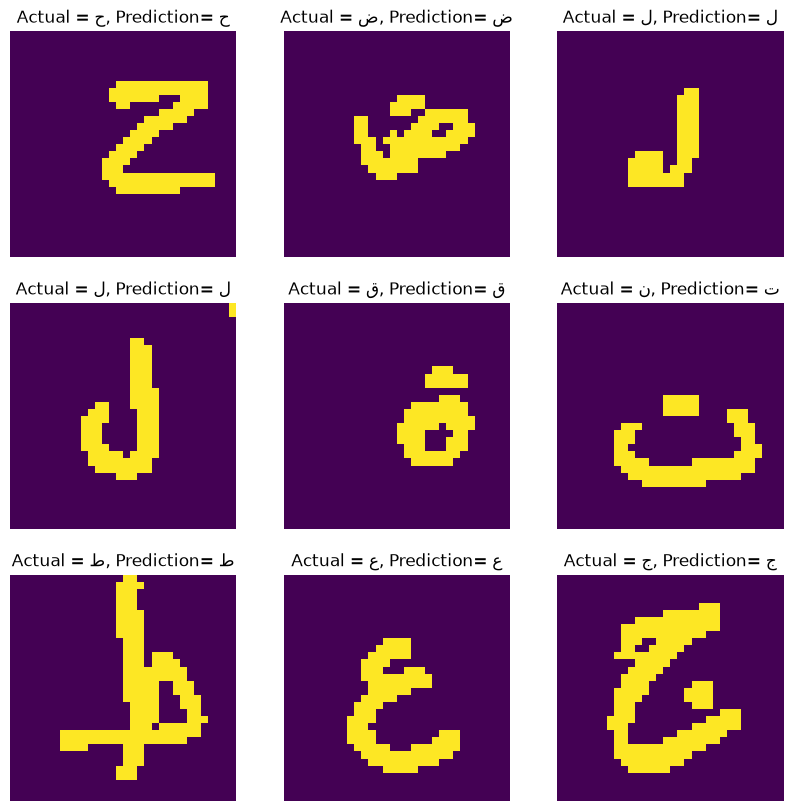

In [15]:
plt.figure(figsize=(10, 10))

for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(new_images[i].numpy().astype("uint8"))
    plt.title(f'Actual = {class_names[new_labels[i]]}, Prediction= {class_names[predictions[i]]}')
    plt.axis("off")

### Saving

In [16]:
model.save('model_1_from_scratch.keras')

## Data Augmentation